(sec:uv_vis)=
# UV/vis absorption/emission

VeloxChem provides UV/vis absorption and emission spectra through two complementary approaches—an eigenvalue‑based TDDFT solver that yields excitation energies and oscillator strengths, and the complex polarization propagator (CPP) approach that computes frequency‑dependent response functions relating directly to broadened, experimentally comparable spectra. For further theoretical details, see {cite}`Norman2018`.

## Generalized eigenvalue equation

The standard method to calculate UV/vis absorption and emission spectra is to solve the generalized eigenvalue equation.

In the case of SCF theory, it is commonly referred to as the time-dependent density functional theory or Hartree–Fock (TDDFT or TDHF) approach. TDHF is also known as the random phase approximation (RPA). 

If electron de-excitations are ignored in the formation of the electronic Hessian, then one arrives at the Tamm–Dancoff approximation and which can be invoked with a keyword in the input file.

VeloxChem implements a reduced-space Davidson algorithm to solve the equation for the *N* lowest eigenvalues (bottom-up). Based on these eigenvalues, or transition frequencies, and the associated transition moments, the dimensionless [oscillator strengths](https://en.wikipedia.org/wiki/Oscillator_strength#:~:text=In%20spectroscopy%2C%20oscillator%20strength%20is,of%20an%20atom%20or%20molecule.) are calculated according to

$$
  f_{n0} = \frac{2 m_\mathrm{e} \omega_{n0}}{3\hbar e^2}
  \sum_{\alpha = x,y,z}
  |\langle 0 | \hat{\mu}_\alpha | n \rangle |^2
$$

With oscillator strengths and transition frequencies, the [linear absorption cross section](https://en.wikipedia.org/wiki/Absorption_cross_section) can be determined from the expression

$$
\sigma(\omega) =
\frac{2\pi^2 e^2 \omega}{(4\pi\varepsilon_0) m_\mathrm{e} c} 
\sum_{n > 0}
f(\omega; \omega_{n0}, \gamma) 
\frac{
f_{n0}
}{ 
\omega_{n0}
}
$$

where $f$ is the [Cauchy distribution](https://en.wikipedia.org/wiki/Cauchy_distribution).

**Python script**

In [3]:
import veloxchem as vlx

molecule = vlx.Molecule.read_name("paranitroaniline")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "cam-b3lyp"
scf_results = scf_drv.compute(molecule, basis)

rsp_drv = vlx.LinearResponseEigenSolver()
rsp_drv.nstates = 5
rsp_results = rsp_drv.compute(molecule, basis, scf_results)

Reading paranitroaniline from PubChem...

Reference: S. Kim, J. Chen, T. Cheng, A. Gindulyte, J. He, S. He, Q. Li, B. A. Shoemaker, P. A. Thiessen, B. Yu, L. Zaslavsky, J. Zhang, E. E. Bolton, Nucleic Acids Res., 2025, 53, D1516-D1525.

Please double-check the compound since names may refer to more than one record.

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Dire

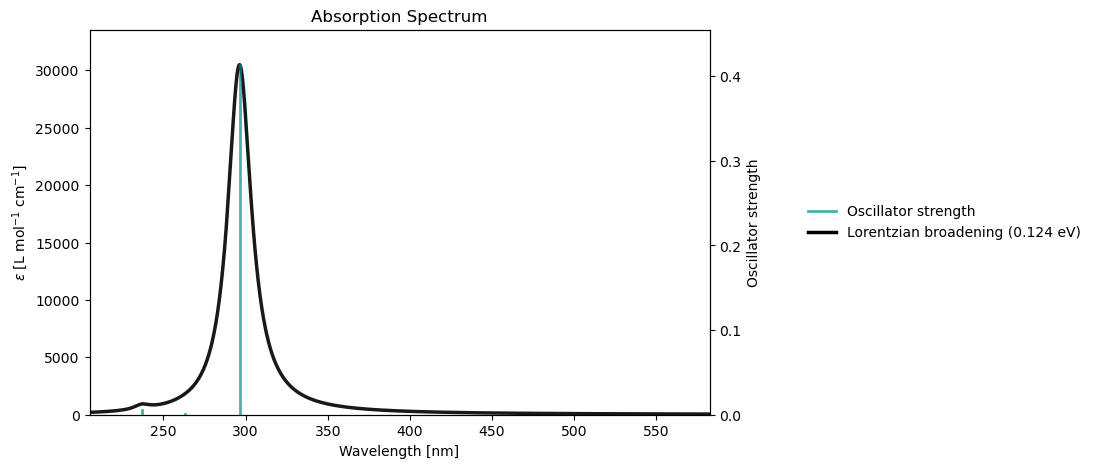

In [5]:
rsp_drv.plot_uv_vis(rsp_results)

**Text file**

Please refer to the [keyword list](#sec:uv-vis-keywords) for a complete set of options. Note that natural transition orbitals NTO can be saved using the `nto` keyword. By specifying the `absorption` property, both UV/vis and ECD spectra will be calculated.

:::{code}
@jobs
task: response
@end

@method settings
xcfun: cam-b3lyp
basis: def2-svp
@end

@response
property: absorption
nstates: 10
nto: yes
@end

@molecule
charge: 0
multiplicity: 1
xyz:  
...
@end
:::

## Complex polarization propagator approach

The linear absorption cross section can be determined directly from the imaginary part of the [polarizability](https://en.wikipedia.org/wiki/Polarizability) {cite}`Norman2018`

$$
\sigma(\omega) =
\frac{\omega}{\epsilon_0 c}
\mathrm{Im}\left\{
\overline{\alpha}(-\omega;\omega)
\right\}
$$

where 

$$
\overline{\alpha} =
\frac{1}{3}
\big(
\alpha_{xx} + 
\alpha_{yy} + 
\alpha_{zz}
\big)
$$

and 

$$
\alpha_{\alpha\beta}(-\omega;\omega) =
- \langle \langle 
\hat{\mu}_\alpha ; \hat{\mu}_\beta
\rangle \rangle^\gamma_\omega
$$

The polarizability is complex and calculated with a damping term, $\hbar \gamma$, associated with the inverse finite lifetime of the excited states. The default program setting for this parameter is 0.124 eV (or 0.004556 a.u.).

The resulting values for $\sigma(\omega)$ are presented in atomic units and can be converted to the SI unit of m$^2$ by multiplying with a factor of $a_0^2$.

The arbitrary frequency region is specified in the input file together with a requested frequency resolution.

**Python script**

In [14]:
import veloxchem as vlx
import numpy as np

molecule = vlx.Molecule.read_name("ethylene")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "cam-b3lyp"
scf_results = scf_drv.compute(molecule, basis)

cpp_drv = vlx.ComplexResponse()
cpp_drv.frequencies = np.arange(0.2, 0.35, 0.0025)
cpp_drv.cpp_flag = "absorption"

cpp_results = cpp_drv.compute(molecule, basis, scf_results)

Reading ethylene from PubChem...

Reference: S. Kim, J. Chen, T. Cheng, A. Gindulyte, J. He, S. He, Q. Li, B. A. Shoemaker, P. A. Thiessen, B. Yu, L. Zaslavsky, J. Zhang, E. E. Bolton, Nucleic Acids Res., 2025, 53, D1516-D1525.

Please double-check the compound since names may refer to more than one record.

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inver

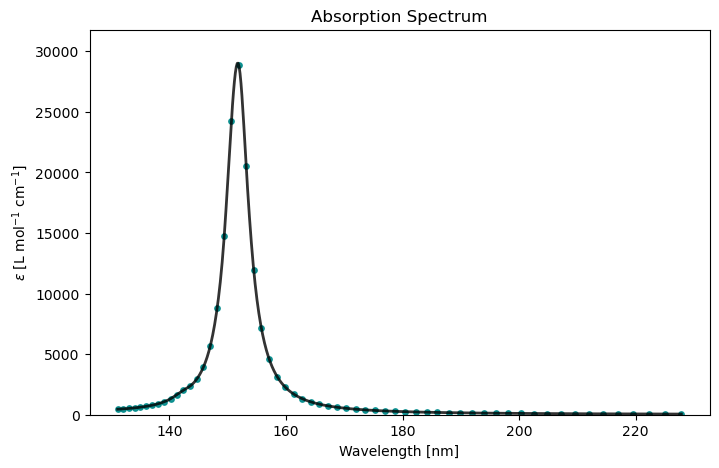

In [17]:
cpp_drv.plot(cpp_results)

**Text file**

:::{code}
@jobs
task: response
@end

@method settings
xcfun: b3lyp
basis: def2-svp
@end

@response
property: absorption (cpp)
! frequency region (and resolution)
frequencies: 0.10-0.25 (0.0025)
damping: 0.0045563  ! this is the default value
@end

@molecule
charge: 0
multiplicity: 1
xyz:  
...
@end 
:::

Please refer to the [keyword list](#sec:cpp-keywords) for a complete set of options.